# Synthetic data VAPOR Guide

In [1]:
# Required Modules
import core as cor
import support as sup
import plotter as plo
import convenience as con
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import Image, display
from astropy import units as u, constants as c
from astropy.constants import au

# constants
sol_radii=695700 # km

%matplotlib inline
#!pip install matplotlib

The Velocity And POsition Reconstruction (VAPOR) mapping tool is designed to perform Line-of-Sight CME tracking in real time with white-light polarization measurements. It relies on scattering geometry of polarized light, and the methods behind this are outlined in https://arxiv.org/pdf/2511.00714. The distance to an object $l$ can be obtained by combining the projected elongation angle $\epsilon$ with measurements of total brightness $(tB)$ and excess polarized brightness $(pB)$, and their ratio $p = pB/tB$. The polarization ratio $(PR)$ can be expressed as a separable function of scattering angle and scattering function (see Billings, 1966; Inhester, 2015).

As the derivation has a built in degeneracy with two output solutions, one positive, the second negative, two solutions are always supplied to the end user, rather than including tracking software to conclude which is the unrealistic solution.


The VAPOR package is comprised of 5 main components:
 - core - which contains the functions used for calculating line of sight distances
 - polarization - a wrapper for the solpolpy package which makes polarization transformation
 - errors - derives error values for each pixel
 - support - these are support modules required by core
 - plotter - contains all plotting algorithms
 - convenience - extra functions for end user convenience, but not always required

To explain each package of functions a series of seperate docs have been generated and should be read in this order for a full understanding:
 - doc_01_overview.ipynb
 - doc_02_convenience.ipynb
 - doc_03_support.ipynb
 - doc_04_core.ipynb
 - doc_05_plotter.ipynb
 - doc_06_overview.ipynb

This document shows basic functionality to produce a plot using synthetic data

In [2]:
# import several data sets at different heights, we show the data from two 
# perspectives, separated by 90 degree to show the change in height of the output

# data at height 1
new_syth_26_90_tb="./test_data/synthetic/synth_026_tB_90.fits"
new_syth_26_0_pb="./test_data/synthetic/synth_026_pB_0.fits"
new_syth_26_0_tb="./test_data/synthetic/synth_026_tB_0.fits"
test_fits_26_90_tb_data, test_fits_hdr = con.open_fits(new_syth_26_90_tb)
test_fits_26_00_tb_data, test_fits_hdr = con.open_fits(new_syth_26_0_tb)
test_fits_26_00_pb_data, test_fits_hdr = con.open_fits(new_syth_26_0_pb)


# out data at height 2
new_syth_36_90_tb="./test_data/synthetic/synth_036_tB_90.fits"
new_syth_36_90_pb="./test_data/synthetic/synth_036_pB_90.fits"

new_syth_36_0_pb="./test_data/synthetic/synth_036_pB_0.fits"
new_syth_36_0_tb="./test_data/synthetic/synth_036_tB_0.fits"
test_fits_36_90_tb_data, test_fits_hdr = con.open_fits(new_syth_36_90_tb)
test_fits_36_00_tb_data, test_fits_hdr = con.open_fits(new_syth_36_0_tb)
test_fits_36_00_pb_data, test_fits_hdr = con.open_fits(new_syth_36_0_pb)


# out data at height 3
new_syth_60_90_tb="./test_data/synthetic/synth_060_tB_90.fits"
new_syth_60_0_pb="./test_data/synthetic/synth_060_pB_0.fits"
new_syth_60_0_tb="./test_data/synthetic/synth_060_tB_0.fits"
test_fits_60_90_tb_data, test_fits_hdr = con.open_fits(new_syth_60_90_tb)
test_fits_60_00_tb_data, test_fits_hdr = con.open_fits(new_syth_60_0_tb)
test_fits_60_00_pb_data, test_fits_hdr = con.open_fits(new_syth_60_0_pb)


# bkg data
pb_00_bkg_fits="./test_data/synthetic/synth_000_pB_0.fits"
tb_00_bkg_fits="./test_data/synthetic/synth_000_tB_0.fits"
pb_90_bkg_fits="./test_data/synthetic/synth_000_pB_90.fits"
tb_90_bkg_fits="./test_data/synthetic/synth_000_tB_90.fits"

test_fits_bk_00_tb_data, test_fits_hdr = con.open_fits(tb_00_bkg_fits)
test_fits_bk_00_pb_data, test_fits_hdr = con.open_fits(pb_00_bkg_fits)

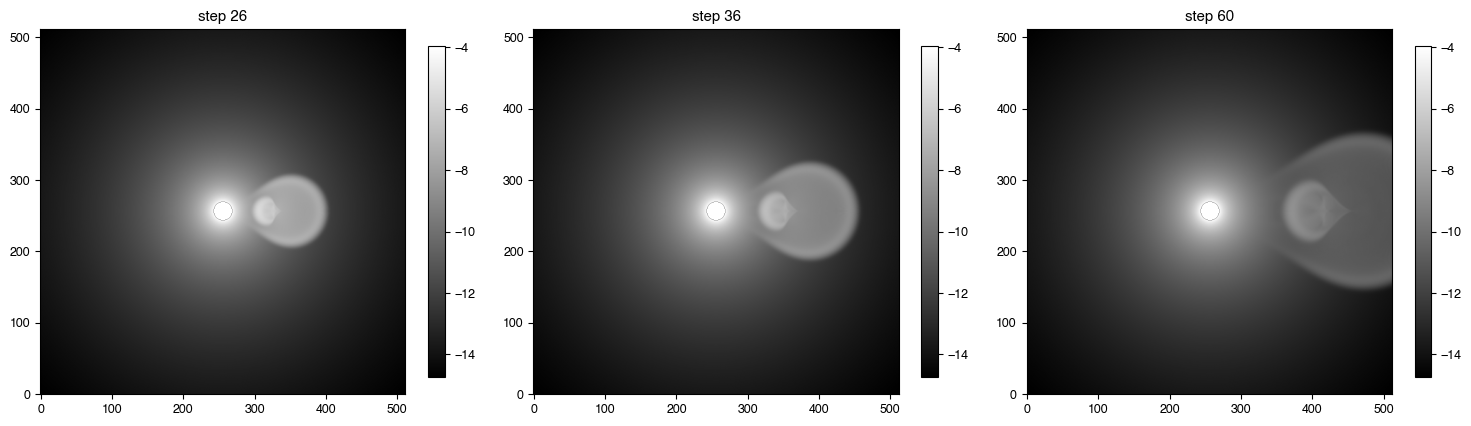

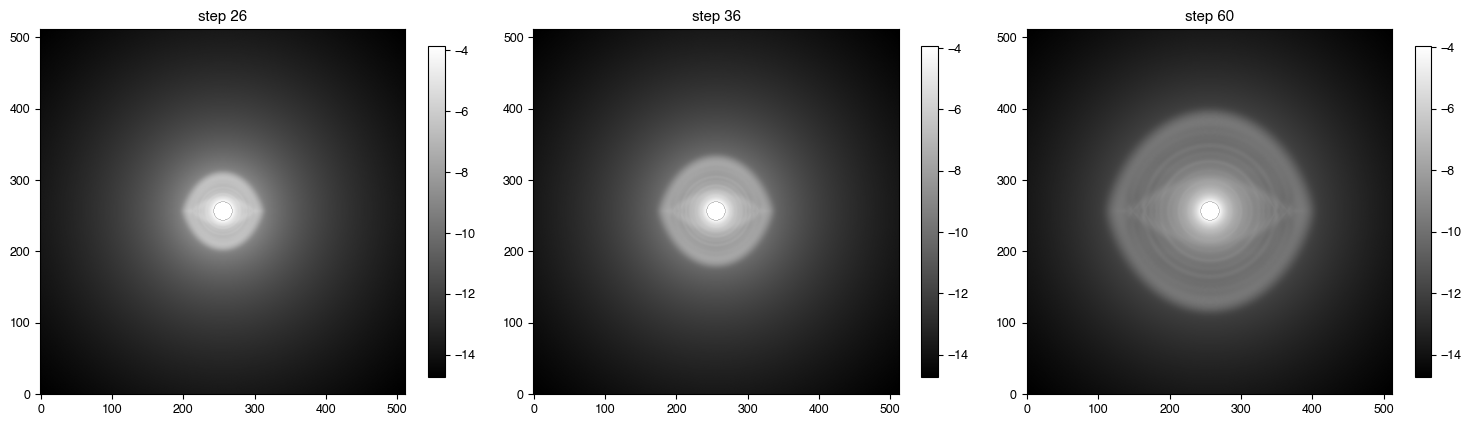

In [3]:
# we show the data from two perspectives, separated bty 90 degree to show the change in height of the output
con.show_3_images(np.log(test_fits_26_90_tb_data), np.log(test_fits_36_90_tb_data), np.log(test_fits_60_90_tb_data), title1="step 26", title2="step 36", title3="step 60" )
con.show_3_images(np.log(test_fits_26_00_tb_data), np.log(test_fits_36_00_tb_data), np.log(test_fits_60_00_tb_data), title1="step 26", title2="step 36", title3="step 60" )

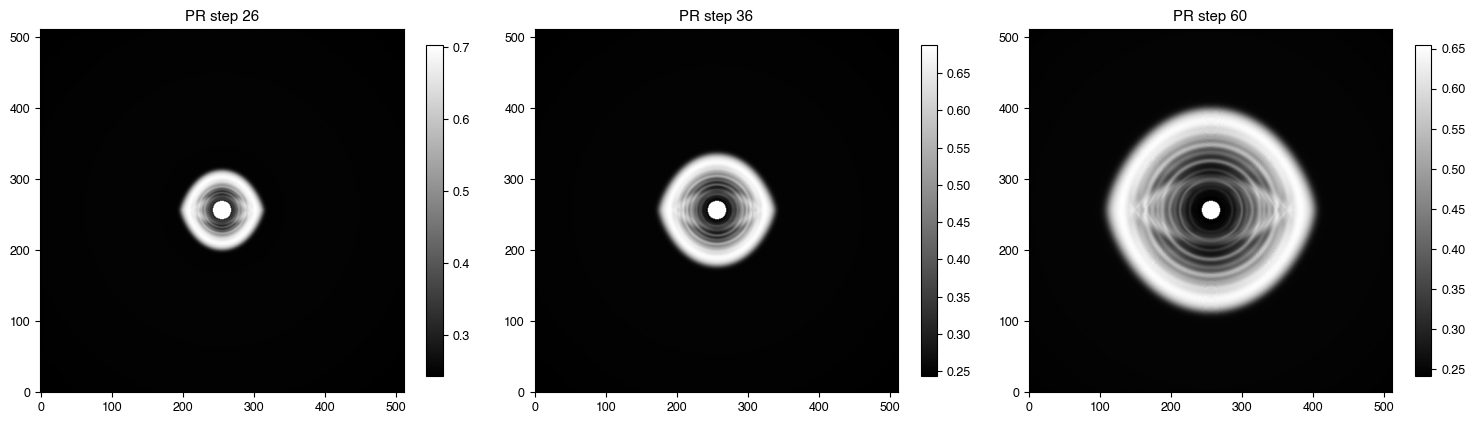

In [4]:
# Next we calculate the Polarization Ratio for each of the heights PR=(tB-pB)/(tB+pB)
PR_26 = cor.radial_position_ps(new_syth_26_0_tb, new_syth_26_0_pb, return_key="PR", use_mask=False)
PR_36 = cor.radial_position_ps(new_syth_36_0_tb, new_syth_36_0_pb, return_key="PR", use_mask=False)
PR_60 = cor.radial_position_ps(new_syth_60_0_tb, new_syth_60_0_pb, return_key="PR", use_mask=False)

# show the three polarization ratios
con.show_3_images(PR_26, PR_36, PR_60, title1="PR step 26", title2="PR step 36", title3="PR step 60" )

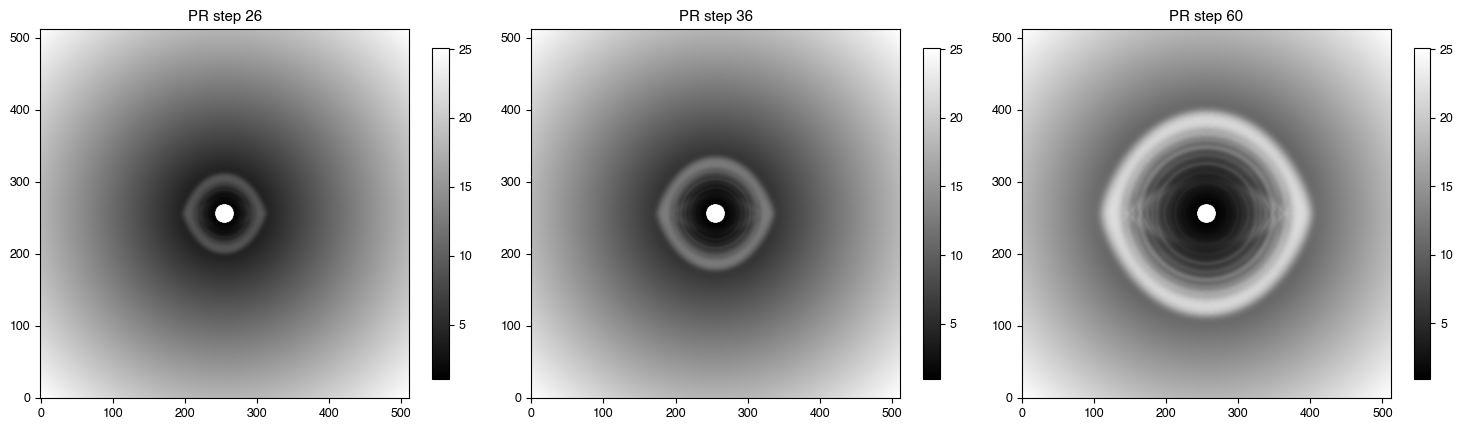

In [5]:
# now we calculate the three 's' front solutions, distance between feature and the Thomson surface
s_front_26 = cor.radial_position_ps(new_syth_26_0_tb, new_syth_26_0_pb, return_key="s_front", use_mask=False)
s_front_36 = cor.radial_position_ps(new_syth_36_0_tb, new_syth_36_0_pb, return_key="s_front", use_mask=False)
s_front_60 = cor.radial_position_ps(new_syth_60_0_tb, new_syth_60_0_pb, return_key="s_front", use_mask=False)

# show the three front solutions in solar radii
con.show_3_images(s_front_26/sol_radii, s_front_36/sol_radii, s_front_60/sol_radii, title1="PR step 26", title2="PR step 36", title3="PR step 60" )

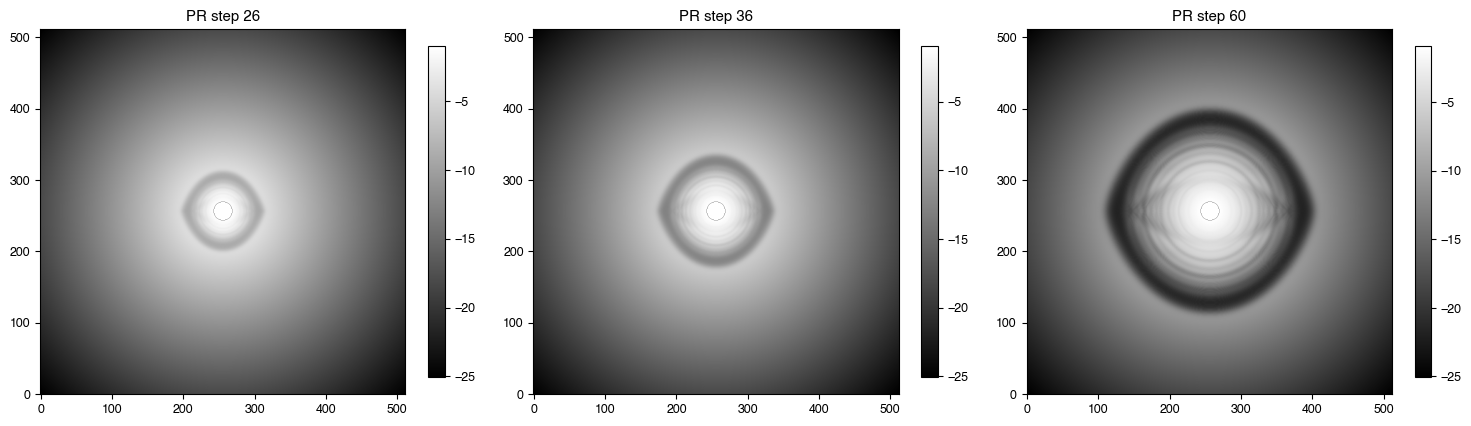

In [6]:
# now we calculate the three back 's' solutions, distance between feature and the Thomson surface - which we know is wrong
s_back_26 = cor.radial_position_ps(new_syth_26_0_tb, new_syth_26_0_pb, return_key="s_back", use_mask=False)
s_back_36 = cor.radial_position_ps(new_syth_36_0_tb, new_syth_36_0_pb, return_key="s_back", use_mask=False)
s_back_60 = cor.radial_position_ps(new_syth_60_0_tb, new_syth_60_0_pb, return_key="s_back", use_mask=False)

# show the three front solutions in solar radii
con.show_3_images(s_back_26/sol_radii, s_back_36/sol_radii, s_back_60/sol_radii, title1="PR step 26", title2="PR step 36", title3="PR step 60" )

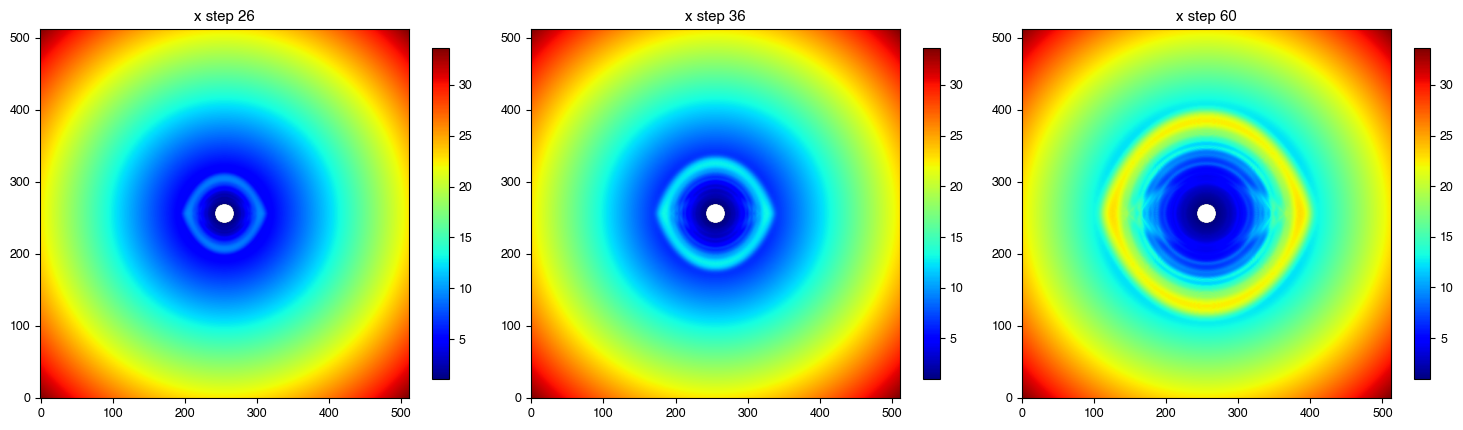

In [7]:
# now Compute distance from plane of sky
x_front_26 = cor.radial_position_ps(new_syth_26_0_tb, new_syth_26_0_pb, return_key="x_front", use_mask=False)
x_front_36 = cor.radial_position_ps(new_syth_36_0_tb, new_syth_36_0_pb, return_key="x_front", use_mask=False)
x_front_60 = cor.radial_position_ps(new_syth_60_0_tb, new_syth_60_0_pb, return_key="x_front", use_mask=False)

# show the three front solutions in solar radii
con.show_3_images(x_front_26/sol_radii, x_front_36/sol_radii, x_front_60/sol_radii, title1="x step 26", title2="x step 36", title3="x step 60", cmap1="jet", cmap2="jet", cmap3="jet")

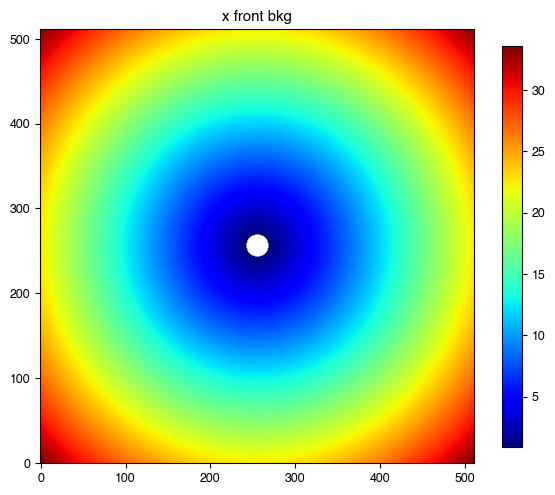

In [8]:
# Now the background is quite distracting, so we will calculate a background solution and subtract it

# background solution
x_front_bkg = cor.radial_position_ps(tb_00_bkg_fits, pb_00_bkg_fits, return_key="x_front", use_mask=False)

# we can see the background solution in this scenario is exactly the same as the background in the simulated CME
con.show_1_image(x_front_bkg/sol_radii, title1="x front bkg", cmap="jet")

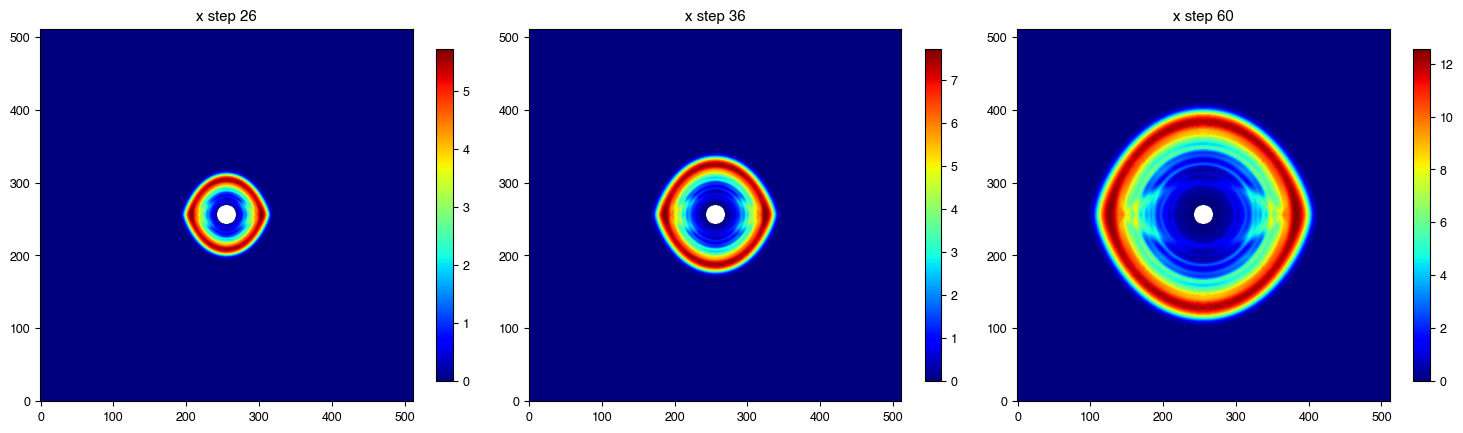

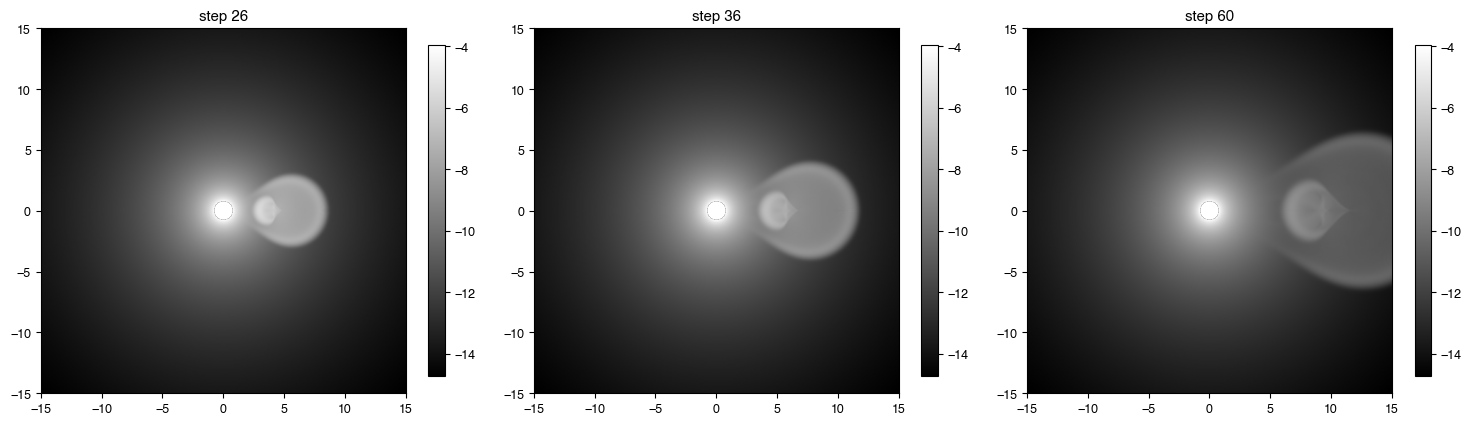

In [9]:
# Now we subtract this bkg and compare the solution to the original data from the other perspective
x_front_26=x_front_26-x_front_bkg
x_front_36=x_front_36-x_front_bkg
x_front_60=x_front_60-x_front_bkg

# show the three solutions; we see the height increasing
con.show_3_images(x_front_26/sol_radii, x_front_36/sol_radii, x_front_60/sol_radii, title1="x step 26", title2="x step 36", title3="x step 60", cmap1="jet", cmap2="jet", cmap3="jet")

# view the other perspective
stereo_extent=[-15, 15, -15, 15]
con.show_3_images(np.log(test_fits_26_90_tb_data), np.log(test_fits_36_90_tb_data), np.log(test_fits_60_90_tb_data), title1="step 26", title2="step 36", title3="step 60", extent1=stereo_extent, extent2=stereo_extent, extent3=stereo_extent)


In [10]:
# Make a Triple plot
plo.create_triple_stereo_plot(
    file_list=[new_syth_36_90_tb, new_syth_36_90_pb],
    data_type="stereo",
    output_method="ps",
    solution="plus",        # back solution
    quantity="los",          # LOS distance
    subtract_base_image=True,
    base_file_list=[tb_90_bkg_fits, pb_90_bkg_fits],
    image_name="./output/LOS_fwd_solution.png",
    plot_min=0,
    plot_max=40,
    verbose=True,
)

x max: LO:S_:fw 8.216249317785733
y max: LO:S_:fw 8.213360034580223


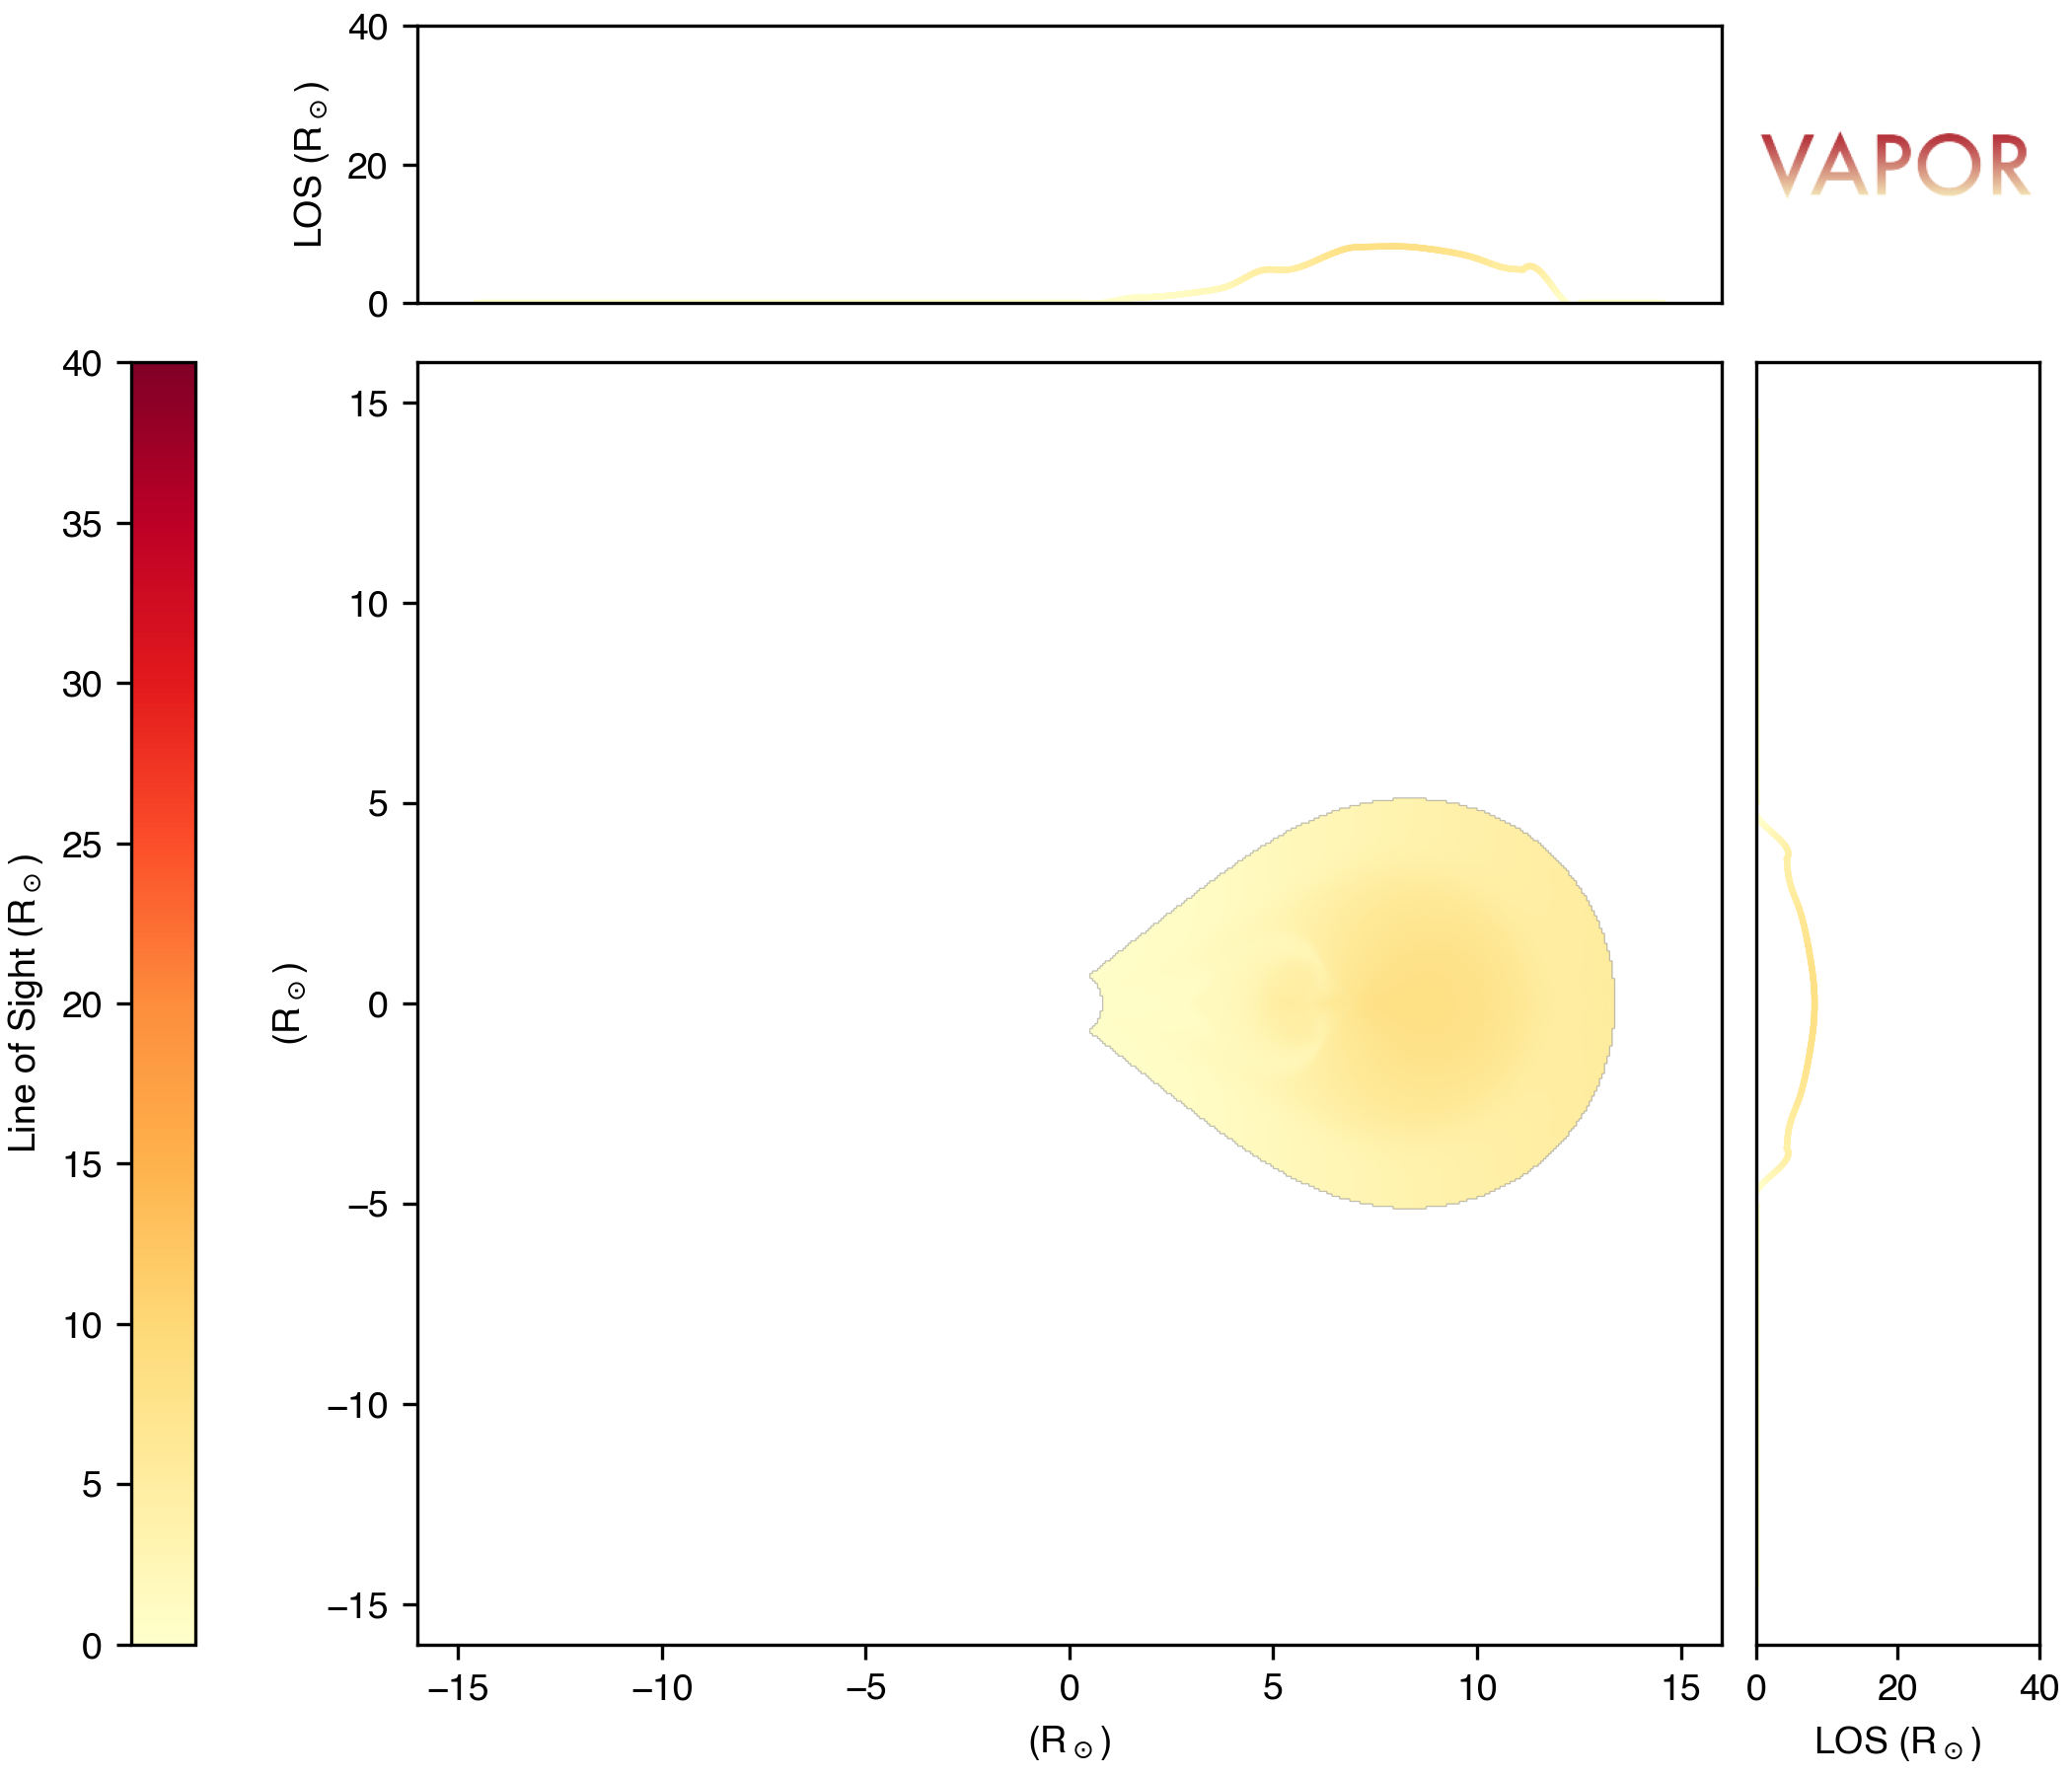

In [11]:
display(Image(filename="./output/LOS_fwd_solution.png"))